<a href="https://colab.research.google.com/github/hjchoi00/AI_lab/blob/main/LAB_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Libraries

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.9.0+cu126


# 2. Load and Explore Data

https://www.kaggle.com/datasets/snmahsa/student-score-suitable-for-linear-regression/data

In [55]:
import pandas as pd

df = pd.read_csv('/content/rounded_hours_student_scores.csv')

print(df.head())

# feature, target 컬럼 지정
feature_cols = ["Hours"]
target_col = "Scores"

X = df[feature_cols].values.astype(np.float32)       # (N, 1)
y = df[target_col].values.astype(np.float32).reshape(-1, 1)  # (N, 1)

print(X.shape, y.shape)


   Hours  Scores
0    1.1      41
1    1.2      40
2    1.4      38
3    1.5      39
4    1.6      36
(60, 1) (60, 1)


In [57]:
# Load student scores dataset
df = pd.read_csv('/content/rounded_hours_student_scores.csv')

# Extract features and target
X = df[['Hours']].values  # (N, 1)
y = df['Scores'].values   # (N,)

print("Dataset Information:")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"\nFeature name: Hours")
print(f"Target: Scores")

# Display statistics
print("\nTarget statistics:")
print(f"  Min: {y.min():.2f}")
print(f"  Max: {y.max():.2f}")
print(f"  Mean: {y.mean():.2f}")

Dataset Information:
Number of samples: 60
Number of features: 1

Feature name: Hours
Target: Scores

Target statistics:
  Min: 36.00
  Max: 65.00
  Mean: 46.43


# 3. Data Preprocessing

In [93]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Normalize features using StandardScaler
# This helps neural networks train faster and more stably
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data normalized (mean=0, std=1)")

Training set size: 48 samples
Test set size: 12 samples

✓ Data normalized (mean=0, std=1)


# 4. Convert to PyTorch Tensors

In [100]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders for batch processing
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Batch size: 64
Number of training batches: 1
Number of test batches: 1


# 5. Model Definition

In [101]:
class RegressionModel(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32):
        super(RegressionModel, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, 1)  # Output layer

    def forward(self, x):
        # Forward pass through the network
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

# Initialize model
input_size = X_train_scaled.shape[1]  # Number of features (1)
model = RegressionModel(input_size).to(device)

print(model)
print(f"\nModel moved to: {device}")

RegressionModel(
  (fc1): Linear(in_features=1, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Model moved to: cuda


# 6. Loss Function and Optimizer

In [102]:
# Loss function: Mean Squared Error
criterion = nn.MSELoss()

# Optimizer: Adam with learning rate 0.001
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss function: {criterion}")
print(f"Optimizer: Adam")
print(f"Learning rate: {learning_rate}")

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001


# 7. Training Loop

In [103]:
# Training parameters
num_epochs = 500

# Track losses for visualization
train_losses = []
test_losses = []

print("Starting training...")
print("-" * 60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Move data to device (GPU if available)
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # 1. Forward pass: compute predictions
        predictions = model(X_batch)

        # 2. Compute loss
        loss = criterion(predictions, y_batch)

        # 3. Backward pass: compute gradients
        optimizer.zero_grad()  # Clear previous gradients
        loss.backward()  # Compute new gradients

        # 4. Update weights
        optimizer.step()

        train_loss += loss.item()

    # Average training loss for this epoch
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Evaluation phase (no gradient computation needed)
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Test Loss: {avg_test_loss:.4f}")

print("-" * 60)
print("Training complete!")

Starting training...
------------------------------------------------------------
Epoch [10/500] | Train Loss: 2121.0146 | Test Loss: 2390.5259
Epoch [20/500] | Train Loss: 2091.7908 | Test Loss: 2356.1912
Epoch [30/500] | Train Loss: 2062.4531 | Test Loss: 2321.0708
Epoch [40/500] | Train Loss: 2029.7227 | Test Loss: 2282.2839
Epoch [50/500] | Train Loss: 1990.4170 | Test Loss: 2235.4939
Epoch [60/500] | Train Loss: 1942.9502 | Test Loss: 2179.0122
Epoch [70/500] | Train Loss: 1885.4144 | Test Loss: 2110.2979
Epoch [80/500] | Train Loss: 1816.5349 | Test Loss: 2028.0297
Epoch [90/500] | Train Loss: 1735.8250 | Test Loss: 1931.5271
Epoch [100/500] | Train Loss: 1643.1357 | Test Loss: 1820.7211
Epoch [110/500] | Train Loss: 1538.8083 | Test Loss: 1695.9584
Epoch [120/500] | Train Loss: 1423.6663 | Test Loss: 1558.4976
Epoch [130/500] | Train Loss: 1299.1960 | Test Loss: 1410.1462
Epoch [140/500] | Train Loss: 1167.5439 | Test Loss: 1253.5513
Epoch [150/500] | Train Loss: 1031.4062 | Tes

# 8. Visualize Training Progress

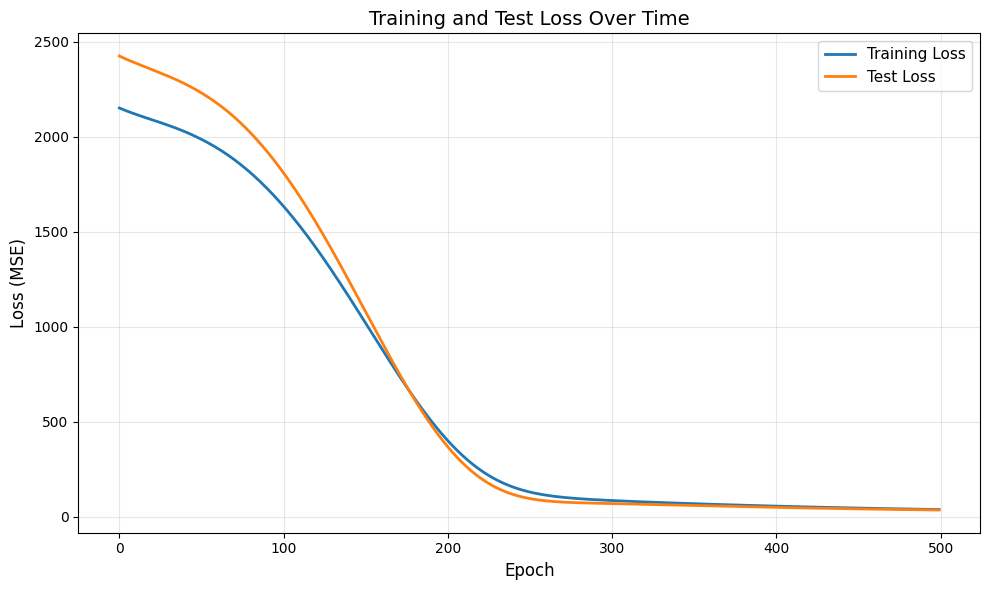

Final Training Loss: 37.6134
Final Test Loss: 35.1481


In [104]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Test Loss Over Time', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")

# 9. Model Evaluation

In [105]:
# Make predictions on test set
model.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_pred = model(X_test_device).cpu().numpy()
    y_true = y_test_tensor.numpy()

# Calculate metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mse)

print("Model Performance on Test Set:")
print("=" * 50)
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print("=" * 50)

print("\nInterpretation:")
print(f"On average, predictions are off by about {mae:.2f} score points.")
print(f"The model explains about {r2*100:.2f}% of the variance in student scores.")


Model Performance on Test Set:
Mean Squared Error (MSE):  35.1481
Root Mean Squared Error (RMSE): 5.9286
Mean Absolute Error (MAE): 5.1926
R² Score: 0.0599

Interpretation:
On average, predictions are off by about 5.19 score points.
The model explains about 5.99% of the variance in student scores.


# 10. Visualize Predictions

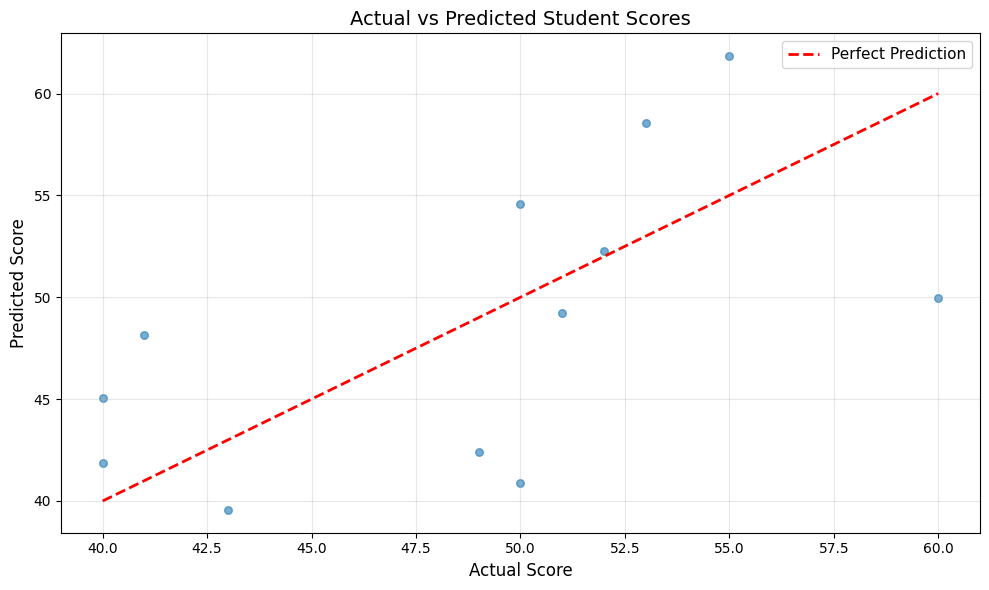


Sample Predictions (first 10 students):
--------------------------------------------------
    Actual |  Predicted |       Diff
--------------------------------------------------
      41.0 |       48.2 |       -7.2
      40.0 |       45.0 |       -5.0
      50.0 |       40.9 |        9.1
      51.0 |       49.2 |        1.8
      40.0 |       41.9 |       -1.9
      53.0 |       58.6 |       -5.6
      43.0 |       39.6 |        3.4
      52.0 |       52.3 |       -0.3
      49.0 |       42.4 |        6.6
      55.0 |       61.8 |       -6.8


In [108]:
# Create scatter plot of predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.6, s=30)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Score', fontsize=12)
plt.ylabel('Predicted Score', fontsize=12)
plt.title('Actual vs Predicted Student Scores', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show some sample predictions
print("\nSample Predictions (first 10 students):")
print("-" * 50)
print(f"{'Actual':>10} | {'Predicted':>10} | {'Diff':>10}")
print("-" * 50)

for i in range(min(10, len(y_true))):
    actual = y_true[i][0]
    predicted = y_pred[i][0]
    diff = actual - predicted
    print(f"{actual:>10.1f} | {predicted:>10.1f} | {diff:>10.1f}")


# 11. Save the Model (Optional)

In [109]:
# Save model
torch.save(model.state_dict(), 'house_price_model.pth')
print("✓ Model saved to 'house_price_model.pth'")

# To load the model later:
# model = RegressionModel(input_size)
# model.load_state_dict(torch.load('house_price_model.pth'))
# model.to(device)
# model.eval()

print("\nTo load this model later, use:")
print("  model = RegressionModel(input_size)")
print("  model.load_state_dict(torch.load('house_price_model.pth'))")
print("  model.to(device)")
print("  model.eval()")

✓ Model saved to 'house_price_model.pth'

To load this model later, use:
  model = RegressionModel(input_size)
  model.load_state_dict(torch.load('house_price_model.pth'))
  model.to(device)
  model.eval()
